In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

import tensorflow as tf

from datasets import load_dataset, Audio as HFAudio

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
print("TensorFlow version:", tf.__version__)
print("Num GPUs available:", len(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.21.0
Num GPUs available: 0


In [3]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
TARGET_SR = 16000

N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256

DURATION = 4.0

MAX_SAMPLES = int(TARGET_SR * DURATION)

print("Target sample rate:", TARGET_SR)
print("Mel bands:", N_MELS)
print("FFT size:", N_FFT)
print("Hop length:", HOP_LENGTH)
print("Maximum samples:", MAX_SAMPLES)

Target sample rate: 16000
Mel bands: 64
FFT size: 1024
Hop length: 256
Maximum samples: 64000


In [5]:
dataset = load_dataset(
    "urgent-challenge/urgent2025-sqa",
    split="blind_test_mos",
    streaming=True
)

dataset = dataset.cast_column(
    "audio",
    HFAudio(decode=True)
)

print("Dataset loaded successfully!")

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Dataset loaded successfully!


In [6]:
samples = []

for i, sample in enumerate(dataset):

    samples.append(sample)

    if i + 1 >= 1000:
        break

print("Samples collected:", len(samples))

Samples collected: 1000


In [7]:
sample = samples[0]

audio = sample["audio"]

waveform = audio.get_all_samples()

audio_array = waveform.data.numpy()
original_sr = waveform.sample_rate

y = audio_array.squeeze()

print("Original sample rate:", original_sr)
print("Number of samples:", len(y))
print("Duration:", len(y) / original_sr)
print("MOS:", sample["mos"])

Original sample rate: 48000
Number of samples: 295158
Duration: 6.149125
MOS: 1.5


In [8]:
def preprocess_audio(sample):

    audio = sample["audio"]

    waveform = audio.get_all_samples()

    audio_array = waveform.data.numpy()

    original_sr = waveform.sample_rate

    y = audio_array.squeeze()

    # Resample
    if original_sr != TARGET_SR:
        y = librosa.resample(
            y,
            orig_sr=original_sr,
            target_sr=TARGET_SR
        )

    # Convert to fixed duration
    if len(y) > MAX_SAMPLES:

        y = y[:MAX_SAMPLES]

    elif len(y) < MAX_SAMPLES:

        padding = MAX_SAMPLES - len(y)

        y = np.pad(
            y,
            (0, padding)
        )

    return y.astype(np.float32)

In [9]:
y_processed = preprocess_audio(samples[0])

print("Processed samples:", len(y_processed))
print("Expected samples:", MAX_SAMPLES)
print("Duration:", len(y_processed) / TARGET_SR)

Processed samples: 64000
Expected samples: 64000
Duration: 4.0


In [10]:
def audio_to_mel(y):

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=TARGET_SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0
    )

    # Convert power spectrogram to decibels
    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return mel_db.astype(np.float32)

In [11]:
mel = audio_to_mel(y_processed)

print("Mel spectrogram shape:", mel.shape)

Mel spectrogram shape: (64, 251)


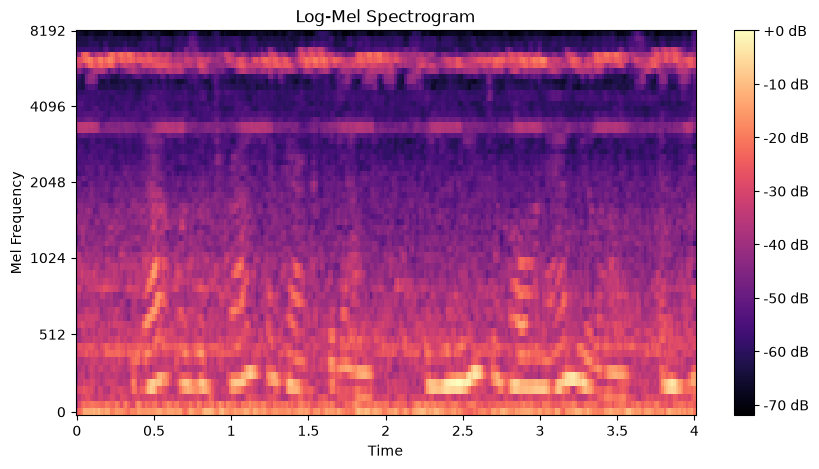

In [12]:
plt.figure(figsize=(10, 5))

librosa.display.specshow(
    mel,
    sr=TARGET_SR,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Log-Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.show()

In [13]:
X_audio = []
y_mos = []

for i, sample in enumerate(samples):

    try:

        audio = preprocess_audio(sample)

        mel = audio_to_mel(audio)

        X_audio.append(mel)

        y_mos.append(sample["mos"])

    except Exception as e:

        print(f"Error processing sample {i}: {e}")

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/1000")

Processed 100/1000
Processed 200/1000
Processed 300/1000
Processed 400/1000
Processed 500/1000
Processed 600/1000
Processed 700/1000
Processed 800/1000
Processed 900/1000
Processed 1000/1000


In [14]:
X_audio = np.array(X_audio, dtype=np.float32)
y_mos = np.array(y_mos, dtype=np.float32)

print("X shape:", X_audio.shape)
print("y shape:", y_mos.shape)

X shape: (1000, 64, 251)
y shape: (1000,)


In [15]:
X_audio = X_audio[..., np.newaxis]

print("CNN input shape:", X_audio.shape)

CNN input shape: (1000, 64, 251, 1)


In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_audio,
    y_mos,
    test_size=0.30,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (700, 64, 251, 1)
Validation: (150, 64, 251, 1)
Testing: (150, 64, 251, 1)


In [17]:
train_mean = X_train.mean()
train_std = X_train.std()

X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("Training mean:", X_train.mean())
print("Training std:", X_train.std())

Training mean: -2.362203e-08
Training std: 1.0


In [18]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    ReLU,
    Dropout,
    GlobalAveragePooling2D,
    Dense
)

In [19]:
model = Sequential([

    Input(
        shape=X_train.shape[1:]
    ),

    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same"
    ),

    BatchNormalization(),

    ReLU(),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same"
    ),

    BatchNormalization(),

    ReLU(),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding="same"
    ),

    BatchNormalization(),

    ReLU(),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    GlobalAveragePooling2D(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="linear"
    )
])

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 251, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 251, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 251, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 125, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 125, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 125, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 125, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 62, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 62, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 31, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,889 (398.00 KB)

 Trainable params: 101,441 (396.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        )
    ]
)

In [22]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6
    )
]

In [23]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=50,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - loss: 0.7695 - mae: 0.6731 - val_loss: 3.0945 - val_mae: 1.6081 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - loss: 0.4924 - mae: 0.5604 - val_loss: 2.4687 - val_mae: 1.4174 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - loss: 0.3738 - mae: 0.4848 - val_loss: 2.4309 - val_mae: 1.4085 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - loss: 0.3596 - mae: 0.4714 - val_loss: 2.6006 - val_mae: 1.4623 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - loss: 0.3664 - mae: 0.4696 - val_loss: 2.2491 - val_mae: 1.3483 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - loss: 0.3668 - mae: 0.4691 - val_loss: 1.9454 - val_mae: 1.2305 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - loss: 0.3603 - mae: 0.4587 - val_loss: 1.8833 - val_mae: 1.2062 - learning_rate: 0.0010
Epoch 8/50
22/22 ━━━

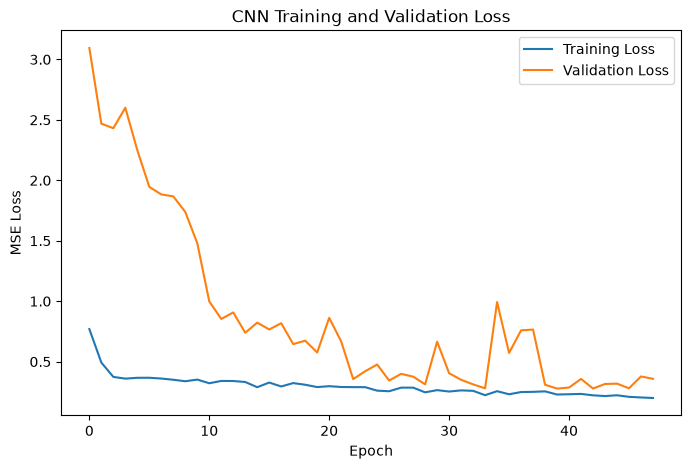

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("CNN Training and Validation Loss")

plt.legend()

plt.show()

In [25]:
test_loss, test_mae_keras = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae_keras)

Test MSE: 0.2681838870048523
Test MAE: 0.3927344083786011


In [26]:
cnn_predictions = model.predict(
    X_test,
    verbose=0
).flatten()

print("First 10 predictions:")
print(cnn_predictions[:10])

First 10 predictions:
[1.5583501 2.3316095 3.0590641 2.0660775 3.1229012 1.3083785 1.7853622
 2.7769954 1.9467866 2.589577 ]


In [27]:
cnn_mae = mean_absolute_error(
    y_test,
    cnn_predictions
)

cnn_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        cnn_predictions
    )
)

cnn_r2 = r2_score(
    y_test,
    cnn_predictions
)

print("CNN Test Results")
print()
print("MAE :", cnn_mae)
print("RMSE:", cnn_rmse)
print("R²  :", cnn_r2)

CNN Test Results

MAE : 0.39273443818092346
RMSE: 0.5178647381361781
R²  : 0.5343518257141113


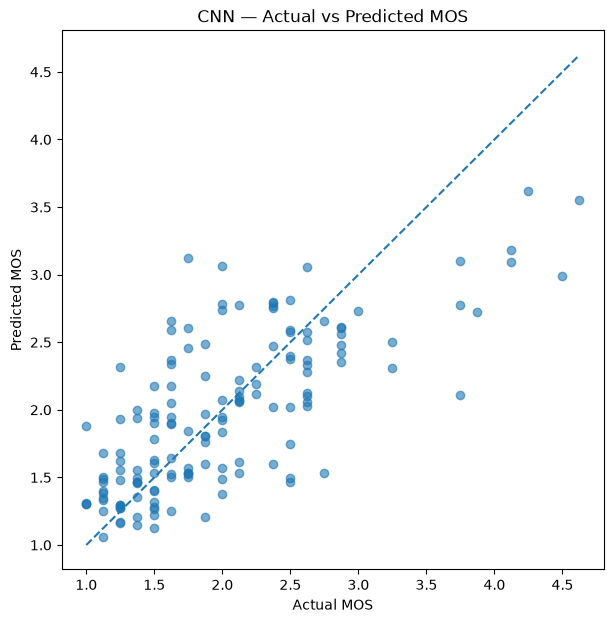

In [28]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    cnn_predictions,
    alpha=0.6
)

min_value = min(
    y_test.min(),
    cnn_predictions.min()
)

max_value = max(
    y_test.max(),
    cnn_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual MOS")
plt.ylabel("Predicted MOS")
plt.title("CNN — Actual vs Predicted MOS")

plt.show()

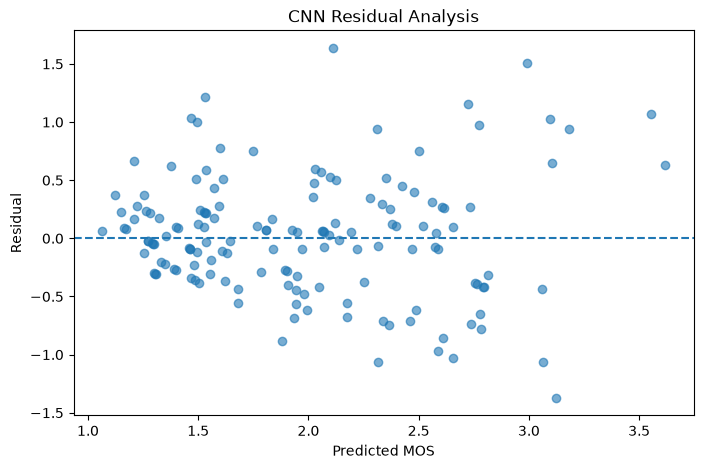

In [29]:
cnn_residuals = y_test - cnn_predictions

plt.figure(figsize=(8, 5))

plt.scatter(
    cnn_predictions,
    cnn_residuals,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted MOS")
plt.ylabel("Residual")
plt.title("CNN Residual Analysis")

plt.show()

In [34]:
classical_metrics = pd.read_csv(
    "../reports/metrics/best_classical_model_metrics.csv"
)

classical_metrics

,Model,MAE,RMSE,R2
0,Random Forest,0.413238,0.511293,0.484022


In [35]:
comparison_df = pd.DataFrame({

    "Model": [
        "CNN",
        classical_metrics.loc[0, "Model"]
    ],

    "MAE": [
        cnn_mae,
        classical_metrics.loc[0, "MAE"]
    ],

    "RMSE": [
        cnn_rmse,
        classical_metrics.loc[0, "RMSE"]
    ],

    "R2": [
        cnn_r2,
        classical_metrics.loc[0, "R2"]
    ]
})

comparison_df

,Model,MAE,RMSE,R2
0,CNN,0.392734,0.517865,0.534352
1,Random Forest,0.413238,0.511293,0.484022


In [31]:
MODEL_DIR = "../models/deep_learning"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

MODEL_PATH = (
    f"{MODEL_DIR}/voiceiq_cnn.keras"
)

model.save(
    MODEL_PATH
)

print("CNN saved successfully!")
print("Path:", MODEL_PATH)

CNN saved successfully!
Path: ../models/deep_learning/voiceiq_cnn.keras


In [32]:
history_df = pd.DataFrame(
    history.history
)

history_path = (
    "../reports/metrics/"
    "cnn_training_history.csv"
)

os.makedirs(
    "../reports/metrics",
    exist_ok=True
)

history_df.to_csv(
    history_path,
    index=False
)

print("Training history saved!")

Training history saved!


In [33]:
cnn_metrics = pd.DataFrame({

    "Model": ["CNN"],

    "MAE": [cnn_mae],

    "RMSE": [cnn_rmse],

    "R2": [cnn_r2]
})

cnn_metrics_path = (
    "../reports/metrics/"
    "cnn_metrics.csv"
)

cnn_metrics.to_csv(
    cnn_metrics_path,
    index=False
)

print("CNN metrics saved!")

CNN metrics saved!
